## Step 2: Spectral extraction

**Tutorial series:**
- [Step 1: Frame sorting](step1_frame_sorting.ipynb)
- **Step 2: Spectral extraction** ← you are here
- [Step 3: Image reconstruction](step3_image_reconstruction.ipynb)

---

This notebook converts the output of `average_to_h5()` into a **coupling-map FITS file** that `CouplingMapModel` in `mapmodel.py` can consume directly.

### What happens here

```
average_map.h5
  avg_PLcam (map_n, map_n, ny, nx)   ← mean detector image per grid bin
        ↓  extract_to_coupling_map(extractor=box_extractor)
coupling_map.fits
  [0] (map_n, map_n, nfib, nwav)     ← mean spectra per bin
  [1] (map_n, map_n)                 ← nframes per bin
  [3] (map_n, map_n, nfib, nwav)     ← variance
  [4] (map_n, map_n, nfib, nwav)     ← normalized variance
        ↓  CouplingMapModel(mapdata=...)
polynomial model → image reconstruction
```

The **extractor** is a plain Python callable `f(image) → (nfib, nwav)`.  
Here we use simple **box extraction**: sum pixel rows within a fixed window around each fiber trace.

In [2]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
import h5py

import PLred.specextract as specextract
import PLred.mapmodel as mapmodel

### 1. Load and inspect the averaged H5

In [22]:
averaged_h5 = 'timestamp_matching_output/average_map.h5'

with h5py.File(averaged_h5, 'r') as f:
    avg_plcam = f['avg_PLcam'][:]           # (map_n, map_n, ny, nx)
    nframes   = f['metadata/nframes'][:]    # (map_n, map_n)
    x_mas     = f['metadata/x_mas'][:]      # (map_n,)
    y_mas     = f['metadata/y_mas'][:]      # (map_n,)

map_n, _, ny, nx = avg_plcam.shape
print(f'map_n={map_n},  ny={ny},  nx={nx}')
print(f'x_mas: {x_mas}')
print(f'y_mas: {y_mas}')
print(f'nframes per bin:\n{nframes}')

map_n=5,  ny=412,  nx=20
x_mas: [-12.96  -6.48   0.     6.48  12.96]
y_mas: [-12.96  -6.48   0.     6.48  12.96]
nframes per bin:
[[0 0 2 1 0]
 [0 4 7 2 0]
 [0 4 9 4 1]
 [1 3 4 1 0]
 [0 0 3 2 0]]


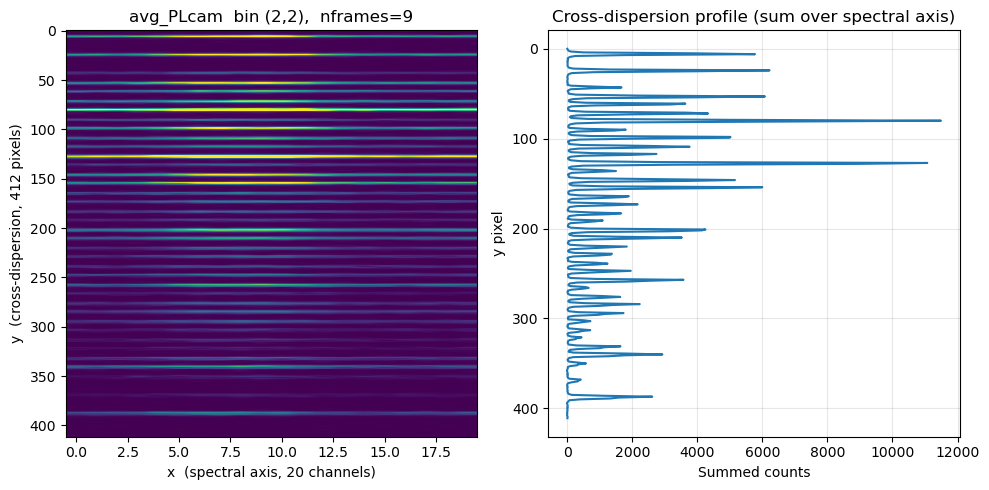

In [23]:
# Visualize the mean PL detector image for the most-populated bin
ix, iy = np.unravel_index(np.argmax(nframes), nframes.shape)
img = avg_plcam[ix, iy]   # (ny=412, nx=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Full image
vmax = np.nanpercentile(img, 99)
axes[0].imshow(img, aspect='auto', vmin=0, vmax=vmax, origin='upper', cmap='viridis')
axes[0].set_xlabel('x  (spectral axis, 20 channels)')
axes[0].set_ylabel('y  (cross-dispersion, 412 pixels)')
axes[0].set_title(f'avg_PLcam  bin ({ix},{iy}),  nframes={nframes[ix,iy]}')

# Cross-dispersion profile (collapse spectral axis)
profile = np.nansum(img, axis=1)   # (ny,)
axes[1].plot(profile, np.arange(ny))
axes[1].invert_yaxis()
axes[1].set_xlabel('Summed counts')
axes[1].set_ylabel('y pixel')
axes[1].set_title('Cross-dispersion profile (sum over spectral axis)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
import importlib
importlib.reload(specextract)

<module 'PLred.specextract' from '/Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/../../PLred/specextract.py'>

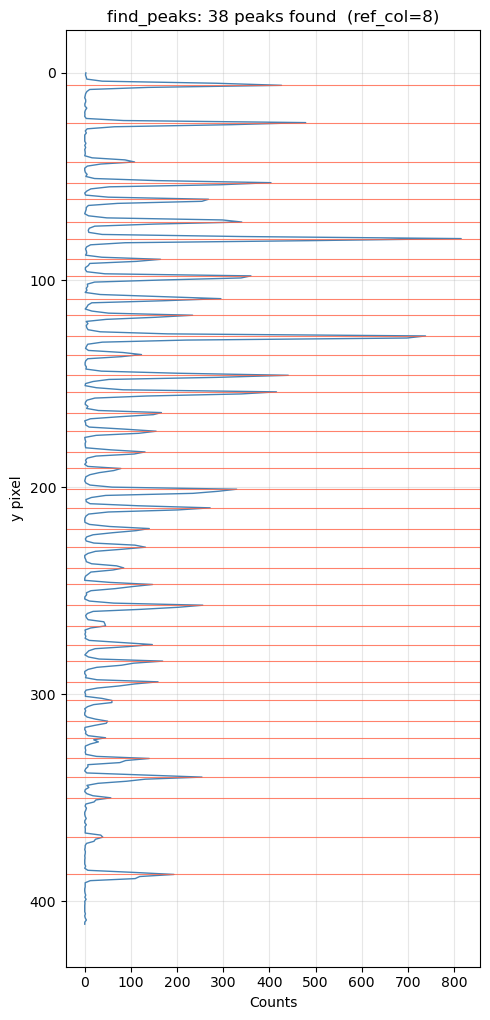

In [25]:
ylocs = specextract.find_peaks(img, nfib=38, thres=0.03, min_dist=6, plot=True)
ylocs = np.sort(ylocs)

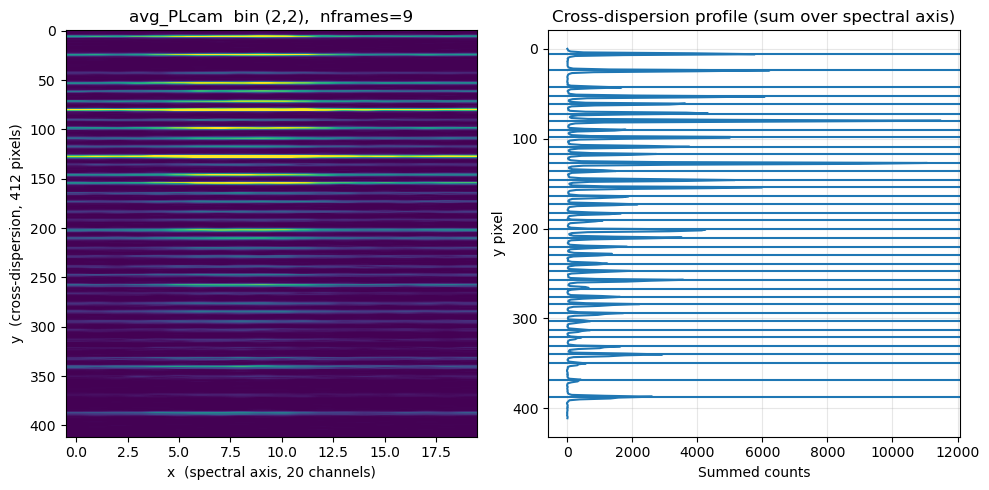

In [26]:
from PLred.IRPLred import spec as irspec

# # locate_spectra iteratively finds the brightest remaining peak, masks it, repeats.
# # num_spec: number of fibers to find.  width: exclusion half-width around each peak.
# # exclude: pixel indices to zero out before searching (e.g. detector edge artefacts).
# ylocs = irspec.locate_spectra(avg_plcam[ix, iy], num_spec=38, width=3,
#                               plot=True, exclude=[0])

# print(f'{len(ylocs)} fiber traces found at y = {sorted(ylocs)}')

# # Visualize the mean PL detector image for the most-populated bin
# ix, iy = np.unravel_index(np.argmax(nframes), nframes.shape)
# img = avg_plcam[ix, iy]   # (ny=412, nx=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Full image
vmax = np.nanpercentile(img, 99)
axes[0].imshow(img, aspect='auto', vmin=0, vmax=vmax, origin='upper', cmap='viridis')
axes[0].set_xlabel('x  (spectral axis, 20 channels)')
axes[0].set_ylabel('y  (cross-dispersion, 412 pixels)')
axes[0].set_title(f'avg_PLcam  bin ({ix},{iy}),  nframes={nframes[ix,iy]}')

# Cross-dispersion profile (collapse spectral axis)
profile = np.nansum(img, axis=1)   # (ny,)
axes[1].plot(profile, np.arange(ny))
axes[1].invert_yaxis()
axes[1].set_xlabel('Summed counts')
axes[1].set_ylabel('y pixel')
axes[1].set_title('Cross-dispersion profile (sum over spectral axis)')
axes[1].grid(alpha=0.3)
for yloc in ylocs:
    axes[1].axhline(yloc)
plt.tight_layout()
plt.show()


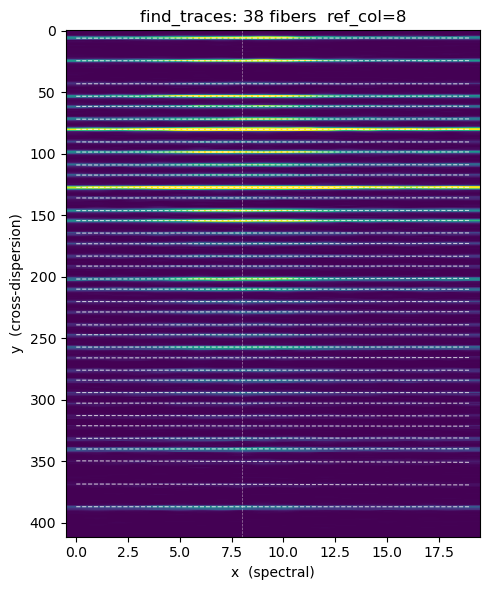

In [27]:
traces = specextract.find_traces(img, 38, 4, plot=True, ini_ys=ylocs, poly_deg=1) #, poly_deg=3,plot=True, ref_col = 10)

In [28]:
my_extractor = specextract.make_trace_extractor(traces, boxsize=3)

### 2. Find fiber trace positions

`IRPLred.spec.locate_spectra()` finds fiber peaks iteratively from the cross-dispersion
profile of the detector image — no manual inspection needed.
In a real pipeline the trace positions come from a bright lamp calibration frame
(neon or flat); here we use the brightest science bin directly.

In [29]:
# from PLred.IRPLred import spec as irspec

# # locate_spectra iteratively finds the brightest remaining peak, masks it, repeats.
# # num_spec: number of fibers to find.  width: exclusion half-width around each peak.
# # exclude: pixel indices to zero out before searching (e.g. detector edge artefacts).
# ylocs = irspec.locate_spectra(avg_plcam[ix, iy], num_spec=38, width=3,
#                               plot=True, exclude=[0])

# print(f'{len(ylocs)} fiber traces found at y = {sorted(ylocs)}')

### 3. Build a box extractor

`specextract.make_irplred_extractor()` wraps `IRPLred.spec.extract_spec` and returns a
ready-to-use callable `f(image) → (nfib, nwav)`.

`dark=None` here because dark subtraction was already applied in `ingest_to_h5` (Step 1).
Pass `dark=dark_frame` if you need to subtract in this step instead.

Extractor output shape: (38, 20)  (nfib=38, nwav=20)


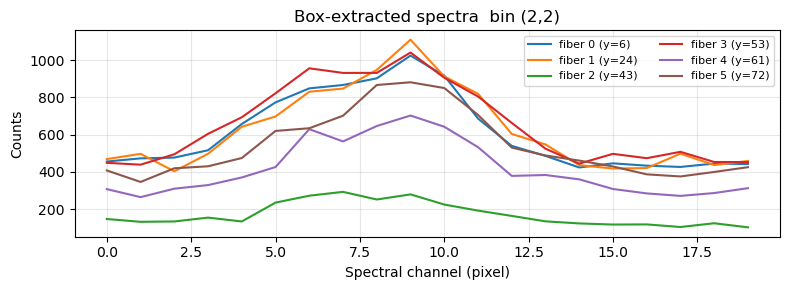

In [30]:
# my_extractor = specextract.make_irplred_extractor(ylocs, width=3, dark=None)

# Sanity check on one image
test_spec = my_extractor(avg_plcam[ix, iy])
print(f'Extractor output shape: {test_spec.shape}  (nfib={len(ylocs)}, nwav={nx})')

# Plot a few fiber spectra
fig, ax = plt.subplots(figsize=(8, 3))
for fib_i in range(min(6, len(ylocs))):
    ax.plot(test_spec[fib_i], label=f'fiber {fib_i} (y={ylocs[fib_i]})')
ax.set_xlabel('Spectral channel (pixel)')
ax.set_ylabel('Counts')
ax.set_title(f'Box-extracted spectra  bin ({ix},{iy})')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3b. Optimal extraction — FIRST-PL / visPLred

This section demonstrates **optimal spectral extraction** using the sparse matrix built by
`SpectrumModel` (see `visPLred/tutorials/pre2_spectrum_model.ipynb`).

### How it relates to box extraction

| | Box extraction | Optimal extraction |
|---|---|---|
| Profile model | Rectangular aperture | Gaussian LSF fitted per column |
| Requires calibration | Trace positions | Full `SpectrumModel` build |
| Cross-talk rejection | None | Yes — LSFs deblend fibers |
| Speed | ~ms per image | ~100ms per image |

### Coordinate system

The spectrum model was built on **uncropped full-detector frames**.
`xmin`/`xmax` in the model file are in **detector pixel coordinates**.

The stored PLcam images in the averaged H5 are typically a hardware-ROI crop of the detector.
`make_FIRSTPL_extractor` needs `plcam_roi = (y0, y1, x0, x1)` — the detector-space bounds of
the stored images — so it can:
1. Slice the image to the model's spectral range: `image[:, xmin-x0 : xmax-x0]`
2. Trim the matrix to the overlap of `[xmin, xmax)` and `[x0, x1)` (if the ROI is narrower)
3. Y-embed if the ROI crops the y-axis (rare)

In [31]:
# ── Step 1: get plcam_roi ────────────────────────────────────────────────────
#
# plcam_roi = (y0, y1, x0, x1) in DETECTOR pixel coordinates of the stored frames.
# Check if it was saved during average_to_h5; otherwise set it manually.

with h5py.File(averaged_h5, 'r') as f:
    if 'metadata/plcam_roi' in f:
        plcam_roi = tuple(int(v) for v in f['metadata/plcam_roi'][:])
        print(f'plcam_roi read from H5: {plcam_roi}')
    else:
        # ▼ Set this to match your actual hardware ROI ▼
        # Format: (y0, y1, x0, x1) in detector pixel coordinates.
        # x0 is the first detector column stored; x1 = x0 + nx.
        # ny, nx of stored images:
        _, _, _ny, _nx = f['avg_PLcam'].shape
        print(f'plcam_roi not in H5 — setting manually.')
        print(f'Stored image size: ny={_ny}, nx={_nx}')
        print(f'  → set x0 such that the model xmin falls within [x0, x0+{_nx})')

        # Example: camera ROI starts at detector column 1100, full detector height
        plcam_roi = (0, 412, 1100, 1100 + _nx)   # ← replace with your actual values
        print(f'plcam_roi (manual): {plcam_roi}')

# ── Step 2: load and inspect the model ──────────────────────────────────────
model_file = 'timestamp_matching_output/model.npz'
model_info = np.load(model_file, allow_pickle=False)

xmin_det = int(model_info['xmin'])
xmax_det = int(model_info['xmax'])
ny_full  = int(model_info['ny_full'])
has_wavmap = 'wav_map' in model_info

print(f'\nModel spectral range (detector coords): [{xmin_det}, {xmax_det})  nwav={xmax_det-xmin_det}')
print(f'Full detector height: {ny_full}')
print(f'Wavelength solution stored: {has_wavmap}')
if has_wavmap:
    wav_map = model_info['wav_map']
    print(f'  wav_map shape: {wav_map.shape}  range: {wav_map.min():.2f}–{wav_map.max():.2f} nm')

# ── Step 3: check overlap ────────────────────────────────────────────────────
roi_x0, roi_x1 = plcam_roi[2], plcam_roi[3]
new_xmin = max(xmin_det, roi_x0)
new_xmax = min(xmax_det, roi_x1)
print(f'\nROI x=[{roi_x0},{roi_x1}),  model x=[{xmin_det},{xmax_det})')
print(f'Overlap (effective extraction range): [{new_xmin},{new_xmax}),  nwav={new_xmax-new_xmin}')
if new_xmin == xmin_det and new_xmax == xmax_det:
    print('→ No trimming needed (model fully inside ROI)')
else:
    print('→ Matrix will be trimmed to overlap region')

plcam_roi read from H5: (0, 412, 1200, 1220)

Model spectral range (detector coords): [1100, 1300)  nwav=200
Full detector height: 412
Wavelength solution stored: True
  wav_map shape: (38, 200)  range: 646.83–667.27 nm

ROI x=[1200,1220),  model x=[1100,1300)
Overlap (effective extraction range): [1200,1220),  nwav=20
→ Matrix will be trimmed to overlap region


In [32]:
# Build the optimal extractor
# ─────────────────────────────────────────────────────────────────────────────
# make_FIRSTPL_extractor loads the matrix, trims it to the ROI overlap, and
# returns a self-contained callable: f(image) → (nfib, nwav_effective).
#
# dark=None because dark subtraction was already done during ingest_to_h5.
# Pass nonlin_modelfile='nonlin_model.fits' if you have a nonlinearity correction.

optimal_extractor = specextract.make_FIRSTPL_extractor(
    model_file  = model_file,
    plcam_roi   = plcam_roi,
    dark        = None,             # dark already subtracted in ingest step
    # nonlin_modelfile = 'path/to/nonlin_model.fits',  # uncomment if needed
)

print('Extractor built.')
print(f"  effective xmin/xmax : [{optimal_extractor._info['xmin']}, {optimal_extractor._info['xmax']})")
print(f"  plcam_roi           : {optimal_extractor._info['plcam_roi']}")
print(f"  wavelength solution : {optimal_extractor._info['has_wavmap']}")

make_FIRSTPL_extractor: model range [1100,1300) trimmed to [1200,1220) to match plcam_roi x=[1200,1220). Output nwav=20 (was 200).
Extractor built.
  effective xmin/xmax : [1200, 1220)
  plcam_roi           : [0, 412, 1200, 1220]
  wavelength solution : True


In [33]:
np.shape(avg_plcam)

(5, 5, 412, 20)

Optimal extraction output shape : (38, 20)
Box extraction output shape     : (38, 20)


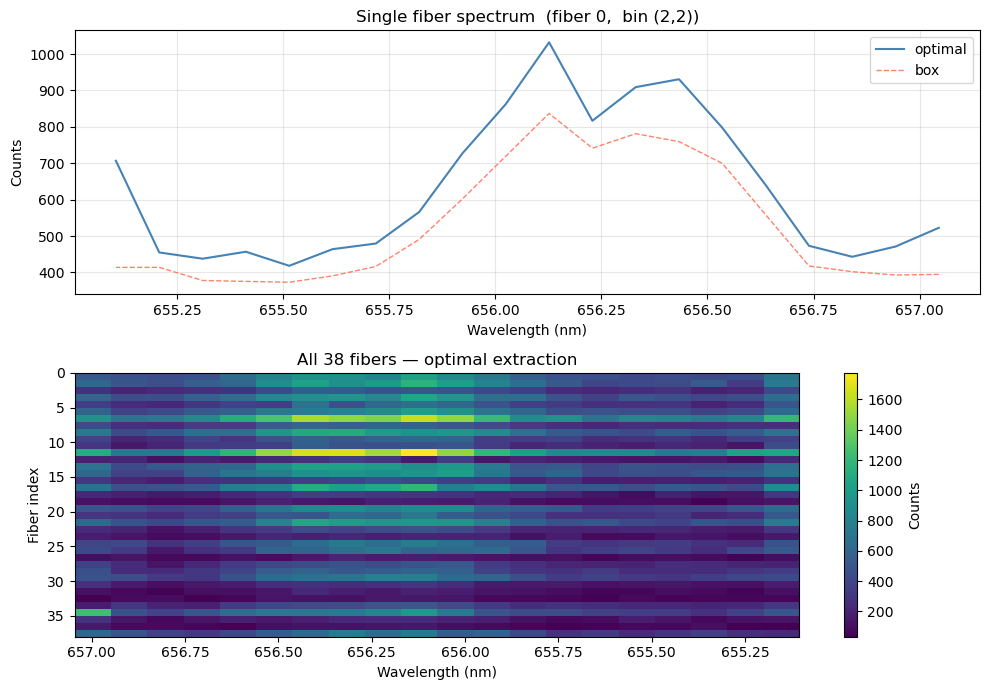

In [34]:
# Test on the brightest bin and compare with box extraction
# ─────────────────────────────────────────────────────────────────────────────
ref_image = np.nanmean(avg_plcam, axis=(0,1))#[ix, iy]          # (412, 20) — the raw ROI image from H5

spec_optimal = optimal_extractor(ref_image)   # (nfib, nwav_effective)
spec_box     = my_extractor(ref_image)        # (nfib, nwav)  from section 3

print(f'Optimal extraction output shape : {spec_optimal.shape}')
print(f'Box extraction output shape     : {spec_box.shape}')

# ── Plot comparison ──────────────────────────────────────────────────────────
nwav_opt = spec_optimal.shape[1]
has_wav  = optimal_extractor._info['has_wavmap']

# x-axis: wavelength (nm) if available, else detector column index
if has_wav:
    # wav_map shape (38, 200) — slice to effective range
    eff_start = optimal_extractor._info['xmin'] - xmin_det
    eff_end   = optimal_extractor._info['xmax'] - xmin_det
    wav_axis  = wav_map[0, eff_start:eff_end]   # ref-fiber wavelengths (nm)
    xlabel    = 'Wavelength (nm)'
else:
    wav_axis = np.arange(nwav_opt)
    xlabel   = 'Spectral channel (pixel)'

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

# ── Top: single fiber spectrum ────────────────────────────────────────────────
fib_i = 0
axes[0].plot(wav_axis, spec_optimal[fib_i], label='optimal', lw=1.5, color='steelblue')
if nwav_opt == spec_box.shape[1]:   # same nwav — direct overlay
    axes[0].plot(wav_axis, spec_box[fib_i],
                 label='box', lw=1, linestyle='--', color='tomato', alpha=0.8)
else:
    axes[0].set_title(f'Fiber {fib_i} spectrum  (box has different nwav — plotted separately)')
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel('Counts')
axes[0].set_title(f'Single fiber spectrum  (fiber {fib_i},  bin ({ix},{iy}))')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Bottom: all 38 fibers ────────────────────────────────────────────────────
im = axes[1].imshow(spec_optimal, aspect='auto', origin='upper',
                    extent=[wav_axis[0], wav_axis[-1], spec_optimal.shape[0], 0],
                    cmap='viridis')
plt.colorbar(im, ax=axes[1], label='Counts')
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel('Fiber index')
axes[1].set_title('All 38 fibers — optimal extraction')

plt.tight_layout()
plt.show()

In [35]:
# Run extract_to_coupling_map with the optimal extractor
# ─────────────────────────────────────────────────────────────────────────────
# The output FITS has shape (map_n, map_n, nfib, nwav_effective) where
# nwav_effective = len(overlap of model range and ROI).
# If a wavelength solution was in the model, spectra are on a common nm grid.

output_fits_optimal = 'timestamp_matching_output/coupling_map_optimal.fits'

specextract.extract_to_coupling_map(
    averaged_h5 = averaged_h5,
    extractor   = optimal_extractor,
    output_fits = output_fits_optimal,
    verbose     = True,
)

Loaded timestamp_matching_output/average_map.h5: map_n=5, avg_PLcam shape=(5, 5, 412, 20)
  dark_subtracted=True (source: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam/dark.fits)
  plcam_roi (det): y=[0,412]  x=[1200,1220]
  model xmin/xmax: [1200,1220]  → image cols [0,20]
  ny_full=412  roi_y0=0  (y-embed=no)
Extractor output shape: nfib=38, nwav=20
Extracting spectra per grid bin...


Extracting: 100%|██████████| 25/25 [00:00<00:00, 130.04it/s]


Variance estimated via Poisson approximation (spectra / nframes).
Coupling map FITS written to: timestamp_matching_output/coupling_map_optimal.fits
  spectra shape : (5, 5, 38, 20)
  valid bins    : 15 / 25


'timestamp_matching_output/coupling_map_optimal.fits'

Optimal coupling map FITS:
  shape       : (5, 5, 38, 20)
  SPEX TYPE   : FIRSTPL_optimal
  SPEX MODEL  : n/a


/var/folders/3q/t9m8zt610pjc_x572xlprc000000gn/T/ipykernel_5005/2859295445.py:20: RuntimeWarning: Mean of empty slice
  mean_box = np.nanmean(data[:, :, fib_i, :], axis=2)         # from box extraction
/var/folders/3q/t9m8zt610pjc_x572xlprc000000gn/T/ipykernel_5005/2859295445.py:21: RuntimeWarning: Mean of empty slice
  mean_opt = np.nanmean(data_opt[:, :, fib_i, :], axis=2)     # from optimal


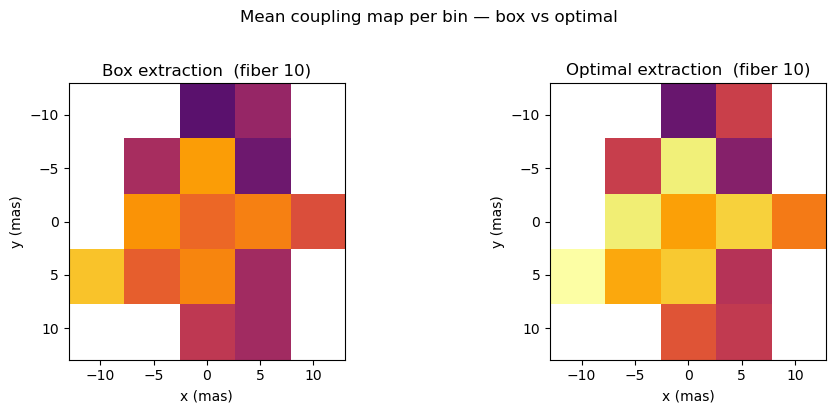


Load the optimal coupling map into CouplingMapModel:
    model = mapmodel.CouplingMapModel(mapdata=output_fits_optimal, min_nframes=2)


In [37]:
# Inspect and compare coupling maps: box vs optimal
# ─────────────────────────────────────────────────────────────────────────────
from astropy.io import fits

with fits.open(output_fits_optimal) as hdul:
    data_opt = hdul[0].data    # (map_n, map_n, nfib, nwav_effective)
    hdr_opt  = hdul[0].header

with fits.open(output_fits) as hdul:
    data = hdul[0].data    # (map_n, map_n, nfib, nwav) from box extraction
    hdr  = hdul[0].header

print('Optimal coupling map FITS:')
print(f'  shape       : {data_opt.shape}')
print(f'  SPEX TYPE   : {hdr_opt.get("HIERARCH SPEX TYPE", "n/a")}')
print(f'  SPEX MODEL  : {hdr_opt.get("HIERARCH SPEX MODEL_F", "n/a")}')

# Mean coupling map: compare box vs optimal for fiber 10
fib_i   = 10
mean_box = np.nanmean(data[:, :, fib_i, :], axis=2)         # from box extraction
mean_opt = np.nanmean(data_opt[:, :, fib_i, :], axis=2)     # from optimal

extent = [x_mas[0], x_mas[-1], y_mas[-1], y_mas[0]]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(np.nanpercentile(mean_box, 98), np.nanpercentile(mean_opt, 98))
kw = dict(extent=extent, origin='upper', cmap='inferno', vmin=0,
          vmax=max(vmax, 1e-6), aspect='equal')

axes[0].imshow(mean_box, **kw)
axes[0].set_title(f'Box extraction  (fiber {fib_i})')
axes[1].imshow(mean_opt, **kw)
axes[1].set_title(f'Optimal extraction  (fiber {fib_i})')

for ax in axes:
    ax.set_xlabel('x (mas)')
    ax.set_ylabel('y (mas)')

plt.suptitle('Mean coupling map per bin — box vs optimal', y=1.02)
plt.tight_layout()
plt.show()

print('\nLoad the optimal coupling map into CouplingMapModel:')
print('    model = mapmodel.CouplingMapModel(mapdata=output_fits_optimal, min_nframes=2)')

### 4. Extract spectra for every grid bin

`extract_to_coupling_map()` loops over all `map_n × map_n` bins, applies the extractor,
and writes a FITS file that `CouplingMapModel` can load directly.

**Variance** falls back to a Poisson approximation here (`var = spectra / nframes`) because
this dataset has no bootstrap resamples. If you ran `average_to_h5(..., n_bootstrap=100)`,
the variance would be estimated from the resamples instead.

In [36]:
output_fits = 'timestamp_matching_output/coupling_map.fits'

specextract.extract_to_coupling_map(
    averaged_h5   = averaged_h5,
    extractor     = my_extractor,
    output_fits   = output_fits,
    use_bootstrap = True,    # uses bootstrap resamples if present, Poisson otherwise
    verbose       = True,
)

Loaded timestamp_matching_output/average_map.h5: map_n=5, avg_PLcam shape=(5, 5, 412, 20)
  dark_subtracted=True (source: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam/dark.fits)
  plcam_roi (det): y=[0,412]  x=[1200,1220]
Extractor output shape: nfib=38, nwav=20
Extracting spectra per grid bin...


Extracting: 100%|██████████| 25/25 [00:00<00:00, 285.89it/s]

Variance estimated via Poisson approximation (spectra / nframes).
Coupling map FITS written to: timestamp_matching_output/coupling_map.fits
  spectra shape : (5, 5, 38, 20)
  valid bins    : 15 / 25
  traces stored : shape (38, 20)


'timestamp_matching_output/coupling_map.fits'

### 5. Inspect the coupling-map FITS

In [8]:
from astropy.io import fits

with fits.open(output_fits) as hdul:
    hdul.info()
    print()
    hdr = hdul[0].header
    print(f"MAP_N = {hdr['MAP_N']},  NFIB = {hdr['NFIB']},  NWAV = {hdr['NWAV']}")
    print(f"XMIN  = {hdr['XMIN']:.2f} mas,  XMAX = {hdr['XMAX']:.2f} mas")
    print()
    data      = hdul[0].data    # (map_n, map_n, nfib, nwav)
    nfr       = hdul[1].data    # (map_n, map_n)
    datavar   = hdul[3].data
    normvar   = hdul[4].data

print('data shape   :', data.shape)
print('nframes shape:', nfr.shape)
print('var shape    :', datavar.shape)
print('normvar shape:', normvar.shape)

Filename: timestamp_matching_output/coupling_map.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  data          1 PrimaryHDU      14   (20, 38, 5, 5)   float32   
  1  nframes       1 ImageHDU         8   (5, 5)   int32   
  2  reserved      1 ImageHDU        10   (20, 38, 5, 5)   float32   
  3  var           1 ImageHDU        10   (20, 38, 5, 5)   float32   
  4  normvar       1 ImageHDU        10   (20, 38, 5, 5)   float32   

MAP_N = 5,  NFIB = 38,  NWAV = 20
XMIN  = -12.96 mas,  XMAX = 12.96 mas

data shape   : (5, 5, 38, 20)
nframes shape: (5, 5)
var shape    : (5, 5, 38, 20)
normvar shape: (5, 5, 38, 20)


### 6. Visualize coupling maps

Each panel below shows the **mean response of one fiber** averaged over all spectral channels,
as a function of the PSF position on the sky grid.

/var/folders/3q/t9m8zt610pjc_x572xlprc000000gn/T/ipykernel_46730/3991739919.py:2: RuntimeWarning: Mean of empty slice
  mean_map = np.nanmean(data, axis=3)   # (map_n, map_n, nfib)


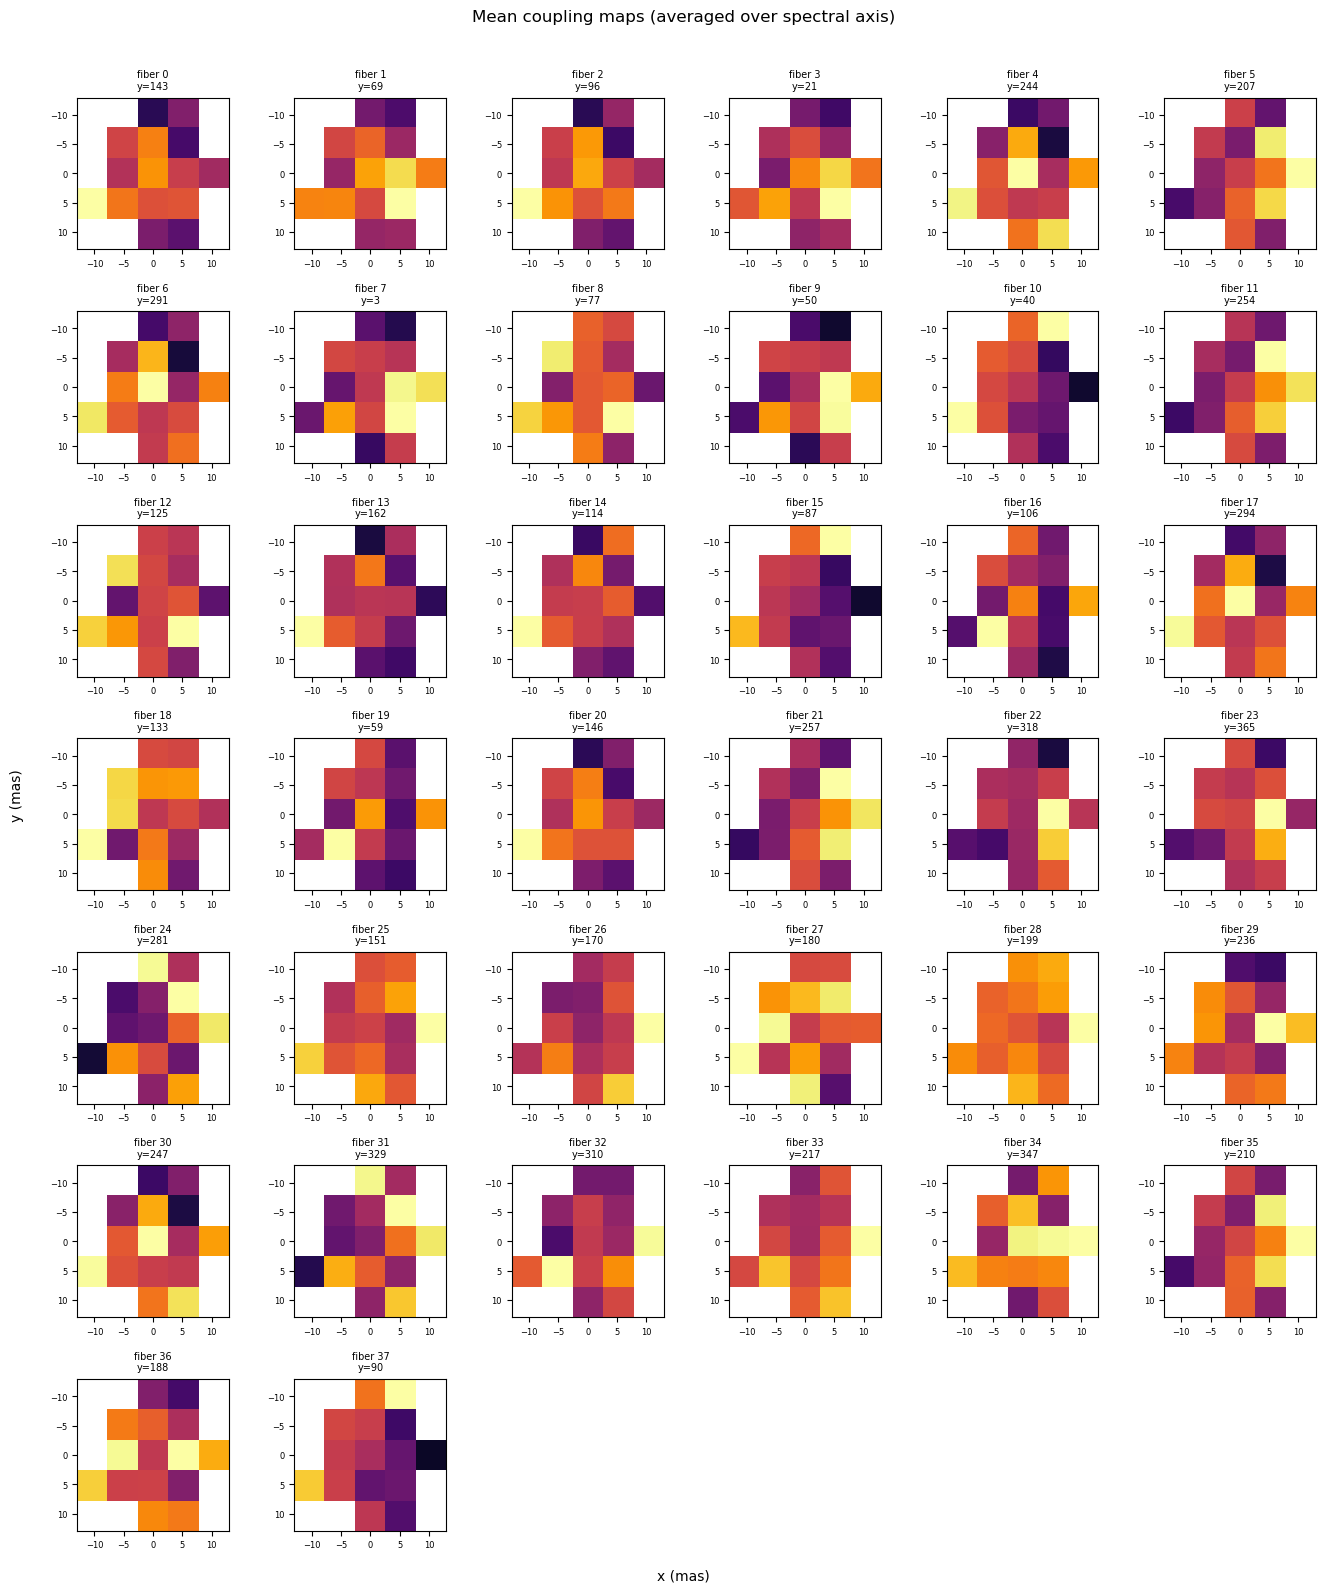

In [9]:
# Mean coupling map per fiber (average over spectral channels)
mean_map = np.nanmean(data, axis=3)   # (map_n, map_n, nfib)

nfib = mean_map.shape[2]
ncols = 6
nrows = int(np.ceil(nfib / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.2))
axes = axes.flatten()

extent = [x_mas[0], x_mas[-1], y_mas[-1], y_mas[0]]  # mas

for fib_i in range(nfib):
    ax = axes[fib_i]
    m = mean_map[:, :, fib_i]
    vmax = np.nanpercentile(m, 98)
    ax.imshow(m, extent=extent, origin='upper', cmap='inferno',
              vmin=0, vmax=max(vmax, 1e-6), aspect='equal')
    ax.set_title(f'fiber {fib_i}\ny={ylocs[fib_i]}', fontsize=7)
    ax.tick_params(labelsize=6)

for ax in axes[nfib:]:
    ax.set_visible(False)

fig.suptitle('Mean coupling maps (averaged over spectral axis)', y=1.01)
fig.text(0.5, -0.01, 'x (mas)', ha='center')
fig.text(-0.01, 0.5, 'y (mas)', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

### 7. Load into CouplingMapModel

The FITS is now compatible with `CouplingMapModel(mapdata=...)` — no conversion needed.

In [10]:
model = mapmodel.CouplingMapModel(mapdata=output_fits, min_nframes=2)

print('normdata shape :', model.normdata.shape)   # (map_n, map_n, nfib, nwav)
print('pos_mas        :', model.pos_mas)
print('nfib           :', model.nfib)

loading mapdata
masking data with less than 2 frames
normdata shape : (5, 5, 38, 20)
pos_mas        : [-12.96  -6.48   0.     6.48  12.96]
nfib           : 38


In [ ]:
# Normalized coupling map for one fiber + one wavelength channel
fib_i   = 0
spec_ch = 10

norm_slice = model.normdata[:, :, fib_i, spec_ch]

plt.figure(figsize=(4, 4))
plt.imshow(norm_slice, extent=extent, origin='upper', cmap='inferno', aspect='equal')
plt.colorbar(label='normalized coupling')
plt.xlabel('x (mas)')
plt.ylabel('y (mas)')
plt.title(f'Normalized coupling map  fiber={fib_i}, ch={spec_ch}')
plt.tight_layout()
plt.show()

### 8. (Optional) Fit a polynomial model

With only 20 spectral channels in this test dataset the polynomial fit is trivial,
but this is the call you would use on real data with hundreds of channels.

In [ ]:
wav_all = np.arange(nx)            # all 20 spectral channel indices

model.make_polynomial_model(
    output_name       = 'timestamp_matching_output/coupling_map_polymodel',
    wav_fitrange      = list(wav_all),
    wav_reconrange    = list(wav_all),
    poly_deg_spatial  = 3,          # keep low — only 5×5 grid
    poly_deg_spectral = 2,          # keep low — only 20 spectral channels
    weighted          = True,
)
print('Polynomial model saved.')

In [ ]:
# Compare measured vs. modeled coupling map for one fiber
fib_i   = 0
spec_ch = 10

measured = model.normdata[:, :, fib_i, spec_ch]
modeled  = model.all_modeled_recons[:, :, fib_i, spec_ch]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
kw = dict(extent=extent, origin='upper', cmap='inferno', aspect='equal')
vmax = np.nanpercentile(measured, 98)

axes[0].imshow(measured, vmin=0, vmax=max(vmax, 1e-9), **kw)
axes[0].set_title(f'Measured  (fiber={fib_i}, ch={spec_ch})')
axes[1].imshow(modeled,  vmin=0, vmax=max(vmax, 1e-9), **kw)
axes[1].set_title('Polynomial model')

for ax in axes:
    ax.set_xlabel('x (mas)')
    ax.set_ylabel('y (mas)')

plt.tight_layout()
plt.show()

---

**Next step:** [Step 3: Image reconstruction](step3_image_reconstruction.ipynb)

Pass the polynomial model FITS to `PLMapFit` to run point-source, Gaussian, or MCMC image reconstruction.